# 3 · Crew races with `CrewRace`

**Use `CrewRace` when boats of different classes (1x, 2x, 4x, 8+ …) with mixed crews race each other on the water**, e.g. a head race where a mixed 4x, a women's 2x and a master's single all start on the same course. Each entry is one boat whose rowers pull *at the same time*.

| Your race | Class |
|---|---|
| team takes turns on **one** erg | `RelayRace` → notebook 1 |
| individuals of different categories, one erg each | `MixedRace` → notebook 2 |
| boats (1x … 8+) with mixed crews on the water | **`CrewRace`** (this notebook) |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))   # use the repo copy of ergrace
%matplotlib inline
import numpy as np
import pandas as pd
pd.set_option("display.precision", 4)

from ergrace import CrewRace, BoatReferences, RelayRace

## Boat references

On the water, the reference depends on the boat class *and* the category: an 8+ is much faster than a 1x. The bundled table holds a 2000 m time for a full crew of each class and category. **These are editable placeholder values** (senior men 1x 6:40 … 8+ 5:20; women about +8 %, juniors +5 %, masters +8 %). Replace them with your own (see the end of this notebook).

In [2]:
BoatReferences.default().table()

,1x,2x,4x,8+
Junior M,7:00.0,6:28.5,6:02.3,5:36.0
Junior W,7:33.6,6:59.6,6:31.2,6:02.9
Master M,7:12.0,6:39.6,6:12.6,5:45.6
Master W,7:46.6,7:11.6,6:42.4,6:13.2
Senior M,6:40.0,6:10.0,5:45.0,5:20.0
Senior W,7:12.0,6:39.6,6:12.6,5:45.6


## A 6 km head race with a staggered start
A crew is `(boat class, rowers)`. The number of rowers must match the boat (coxswains are not listed).


           CREW RACE 6000 m: STAGGERED START (expected level 70% of reference power)            
 Start #     Entry                          Category Expected Time Start Offset Gap to Prev (s)
       1 Master 1x                         1x: Mas M       24:19.6      +0:00.0             0.0
       2  Women 2x                       2x: 2 Sen W       22:30.1      +1:49.5           109.5
       3 Junior 4x                       4x: 4 Jun W       22:01.8      +2:17.9            28.4
       4  Mixed 4x 4x: Jun M + Sen M + Jun W + Sen W       20:37.5      +3:42.1            84.3
       5  Mixed 8+             8+: 4 Sen M + 4 Sen W       18:41.1      +5:38.5           116.4



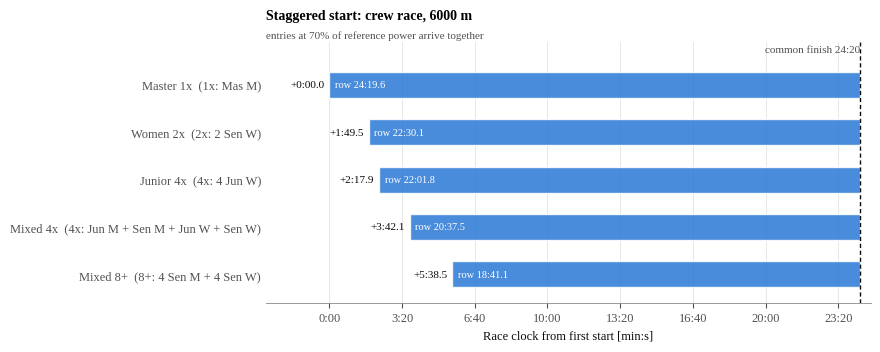

In [3]:
crews = {
    "Mixed 4x":  ("4x", ["Senior M", "Senior W", "Junior M", "Junior W"]),
    "Women 2x":  ("2x", ["Senior W", "Senior W"]),
    "Master 1x": ("1x", "Master M"),
    "Mixed 8+":  ("8+", {"Senior M": 4, "Senior W": 4}),
    "Junior 4x": ("4x", {"Junior W": 4}),
}
head = CrewRace(distance=6000, crews=crews, level=0.7)
head.print_handicaps()
head.plot_handicaps();


                            CREW RACE 6000 m: RESULTS (Score = fraction of reference power)                            
 Rank     Entry                          Category    Time Split /500 m Speed Score  Score  Line Order Vs Handicap (s)
    1  Mixed 8+             8+: 4 Sen M + 4 Sen W 18:20.0       1:31.7      0.9050 0.7411           1         -0:21.1
    2  Women 2x                       2x: 2 Sen W 22:10.0       1:50.8      0.9014 0.7323           2         -0:20.1
    3 Junior 4x                       4x: 4 Jun W 21:45.0       1:48.8      0.8993 0.7273           3         -0:16.8
    4  Mixed 4x 4x: Jun M + Sen M + Jun W + Sen W 20:52.0       1:44.3      0.8776 0.6759           4         +0:14.5
    5 Master 1x                         1x: Mas M 24:40.0       2:03.3      0.8757 0.6715           5         +0:20.4



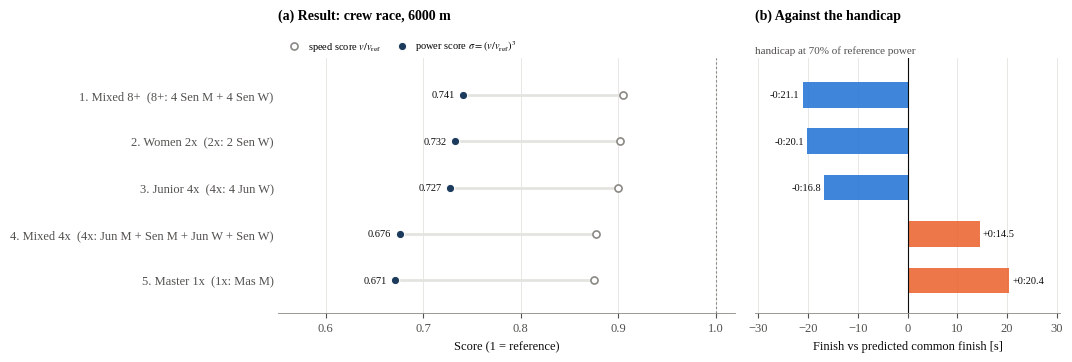

In [4]:
head.record({"Mixed 4x": "20:52", "Women 2x": "22:10", "Master 1x": "24:40",
             "Mixed 8+": "18:20", "Junior 4x": "21:45"})
head.print_results()
head.plot_results();

---
## Limit cases

### 1 · A homogeneous crew reproduces its table entry

In [5]:
single = CrewRace(distance=2000, crews={"M 1x": ("1x", "Senior M"), "W 8+": ("8+", {"Senior W": 8})})
single.handicaps()[["Entry", "Category", "Expected Time"]]

,Entry,Category,Expected Time
0,M 1x,1x: Sen M,6:40.0
1,W 8+,8+: 8 Sen W,5:45.6


### 2 · Why a crew is **not** combined like a relay
The same four people, a senior man, a senior woman, a junior man and a junior woman, are combined differently depending on how they row together:

* **Crew boat:** all seats move at one speed and their **powers add**. The reference speed is $(\overline{v^3})^{1/3}$, a power mean with exponent 3.
* **Relay, swapping on the clock:** their **distances** add, giving the plain mean of speeds.
* **Relay, equal legs:** their **times** add, giving the harmonic mean.

Averaging powers favours the stronger rowers more than averaging speeds does. Mixing up the rules gives a biased reference; the RRC 2026 report shows this for relays.

In [6]:
people = ["Senior M", "Senior W", "Junior M", "Junior W"]
boat = BoatReferences.default()
v = np.array([boat.speed("4x", p) for p in people])
means = {"exponent -1 (harmonic, equal legs)": len(v) / np.sum(1 / v),
         "exponent 1 (arithmetic, swap on clock)": v.mean(),
         "exponent 3 (seat powers add: crew boat)": np.mean(v ** 3) ** (1 / 3)}
pd.DataFrame({"reference speed (m/s)": means,
              "4x time 2000 m (s)": {k: 2000 / x for k, x in means.items()}})

,reference speed (m/s),4x time 2000 m (s)
"exponent -1 (harmonic, equal legs)",5.4381,367.7750
"exponent 1 (arithmetic, swap on clock)",5.4494,367.0137
exponent 3 (seat powers add: crew boat),5.4607,366.2557


In [7]:
crew4 = CrewRace(distance=2000, crews={"mixed 4x": ("4x", people)})
print(crew4.handicaps()[["Entry", "Category", "Expected Time"]].to_string(index=False))

   Entry                          Category Expected Time
mixed 4x 4x: Jun M + Sen M + Jun W + Sen W        6:06.3


### 3 · Long head races and fatigue
The references are 2000 m times. For a 6 km course, `fatigue=5` (Paul's law, +5 s/500 m per doubling of distance) gives more realistic absolute times. Because every boat rows the same distance, the correction adds the same time to everyone: **the start offsets do not change**, only the predicted times (and therefore the scores after the race).

In [8]:
for f in (None, 5):
    hc = CrewRace(distance=6000, crews=crews, level=0.7, fatigue=f).handicaps()
    print(f"fatigue={f}")
    print(hc[["Entry", "Expected Time", "Start Offset"]].to_string(index=False), "\n")

fatigue=None
    Entry Expected Time Start Offset
Master 1x       24:19.6      +0:00.0
 Women 2x       22:30.1      +1:49.5
Junior 4x       22:01.8      +2:17.9
 Mixed 4x       20:37.5      +3:42.1
 Mixed 8+       18:41.1      +5:38.5 

fatigue=5
    Entry Expected Time Start Offset
Master 1x       26:06.7      +0:00.0
 Women 2x       24:17.2      +1:49.5
Junior 4x       23:48.9      +2:17.9
 Mixed 4x       22:24.6      +3:42.1
 Mixed 8+       20:28.2      +5:38.5 



### 4 · Timed crew race
With `time=...` the result is a distance, and the handicap is a target distance / metre credit per boat.


   CREW RACE 20:00: TARGET DISTANCES (expected level 70% of reference power)    
    Entry                          Category Target Distance (m) Credit (m)
Master 1x                         1x: Mas M                4933       1489
 Women 2x                       2x: 2 Sen W                5333       1089
Junior 4x                       4x: 4 Jun W                5447        975
 Mixed 4x 4x: Jun M + Sen M + Jun W + Sen W                5818        604
 Mixed 8+             8+: 4 Sen M + 4 Sen W                6422          0



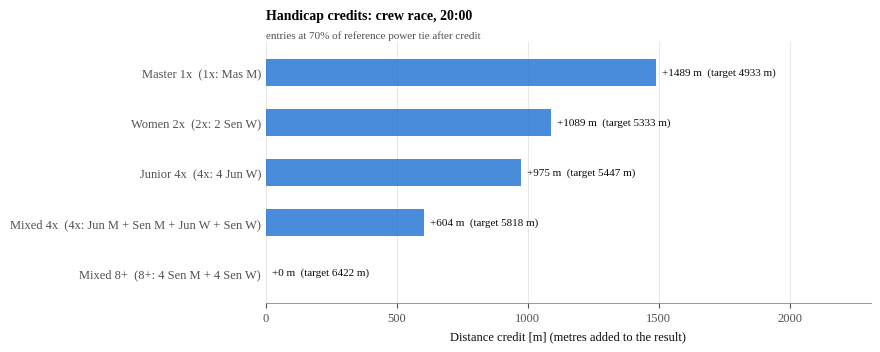

In [9]:
timed = CrewRace(time="20:00", crews=crews, level=0.7)
timed.print_handicaps()
timed.plot_handicaps();

### 5 · Invalid crews are caught

In [10]:
try:
    CrewRace(distance=2000, crews={"too few": ("4x", ["Senior M"] * 3)})
except ValueError as err:
    print("error:", err)

error: 'too few': a 4x has 4 rowing seat(s), got 3 rower(s)


## Your own boat references

In [11]:
my_boats = BoatReferences(2000, {
    "1x": {"Senior M": "7:05", "Senior W": "7:55", "Master M": "7:30"},
    "2x": {"Senior M": "6:35", "Senior W": "7:20"},
    "4x": {"Senior M": "6:10", "Senior W": "6:50", "Junior W": "7:05"},
})
CrewRace(distance=5000, references=my_boats, level=0.8, crews={
    "Mixed 2x": ("2x", ["Senior M", "Senior W"]),
    "W 4x": ("4x", {"Senior W": 2, "Junior W": 2}),
    "Master 1x": ("1x", "Master M"),
}).print_handicaps()


     CREW RACE 5000 m: STAGGERED START (expected level 80% of reference power)      
 Start #     Entry              Category Expected Time Start Offset Gap to Prev (s)
       1 Master 1x             1x: Mas M       20:11.9      +0:00.0             0.0
       2      W 4x 4x: 2 Jun W + 2 Sen W       18:43.6      +1:28.2            88.2
       3  Mixed 2x     2x: Sen M + Sen W       18:37.8      +1:34.0             5.8

